<a href="https://colab.research.google.com/github/celiablanco/YSPLanguageComplexity2026/blob/divya-work-part-2/YSP_Task_Wikipedia_Water.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import os

os.makedirs("wikipedia_texts", exist_ok=True)

HEADERS = {
    "User-Agent": "YSP-LanguageComplexity-Research/1.0 (BMSIS Young Scientist Program; contact: divyashuklaa15@@gmail.com)"
}

def get_article_text(lang, title):
    url = f"https://{lang}.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "titles": title,
        "prop": "extracts",
        "explaintext": True,
        "format": "json"
    }
    response = requests.get(url, params=params, headers=HEADERS)
    response.raise_for_status()
    data = response.json()

    pages = data["query"]["pages"]
    page = next(iter(pages.values()))
    return page.get("extract", "")

text = get_article_text("en", "Water")

with open("wikipedia_texts/en.txt", "w", encoding="utf-8") as f:
    f.write(text)

print(f"Fetched and saved English 'Water' article: {len(text)} characters, {len(text.split())} words")

Fetched and saved English 'Water' article: 69797 characters, 11061 words


In [ ]:
!pip install deep-translator -q

os.makedirs("source_wikipedia", exist_ok=True)
os.makedirs("translated_wikipedia_en", exist_ok=True)

with open("wikipedia_texts/en.txt", "r", encoding="utf-8") as f:
    text = f.read()

with open("source_wikipedia/input_en.txt", "w", encoding="utf-8") as f:
    f.write(text)

print(f"Loaded {len(text)} characters, {len(text.split())} words")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.6 MB/s eta 0:00:00
Loaded 69797 characters, 11061 words


In [ ]:
def split_into_chunks_by_paragraph(text, max_chars=4000):
    paragraphs = text.split("\n\n")
    chunks = []
    current = ""

    for para in paragraphs:
        para = para.strip()
        if not para:
            continue
        if len(current) + len(para) + 2 <= max_chars:
            current += ("\n\n" if current else "") + para
        else:
            if current:
                chunks.append(current)
            current = para

    if current:
        chunks.append(current)

    return chunks

chunks = split_into_chunks_by_paragraph(text)
print(f"Split into {len(chunks)} chunks")

Split into 22 chunks


In [ ]:
from deep_translator import GoogleTranslator
import time

supported = GoogleTranslator().get_supported_languages(as_dict=True)

def translate_article(chunks, target_code):
    translated_chunks = []
    for chunk in chunks:
        result = GoogleTranslator(source='en', target=target_code).translate(chunk)
        translated_chunks.append(result)
        time.sleep(0.2)
    return "\n\n".join(translated_chunks)

total = len(supported)
completed = 0
failed = []

for i, (name, code) in enumerate(supported.items(), start=1):
    out_path = f"translated_wikipedia_en/{code}.txt"

    if os.path.exists(out_path):
        print(f"[{i}/{total}] {name} -> already done, skipping")
        completed += 1
        continue

    try:
        full_translation = text if code == "en" else translate_article(chunks, code)
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(full_translation)
        print(f"[{i}/{total}] {name} -> DONE")
        completed += 1
    except Exception as e:
        print(f"[{i}/{total}] {name} -> FAILED: {e}")
        failed.append(code)

    time.sleep(0.3)

print(f"\n=== {completed}/{total} completed, {len(failed)} failed ===")

[1/133] afrikaans -> DONE
[2/133] albanian -> DONE
[3/133] amharic -> DONE
[4/133] arabic -> DONE
[5/133] armenian -> DONE
[6/133] assamese -> DONE
[7/133] aymara -> DONE
[8/133] azerbaijani -> DONE
[9/133] bambara -> DONE
[10/133] basque -> DONE
[11/133] belarusian -> DONE
[12/133] bengali -> DONE
[13/133] bhojpuri -> DONE
[14/133] bosnian -> DONE
[15/133] bulgarian -> DONE
[16/133] catalan -> DONE
[17/133] cebuano -> DONE
[18/133] chichewa -> DONE
[19/133] chinese (simplified) -> DONE
[20/133] chinese (traditional) -> DONE
[21/133] corsican -> DONE
[22/133] croatian -> DONE
[23/133] czech -> DONE
[24/133] danish -> DONE
[25/133] dhivehi -> DONE
[26/133] dogri -> DONE
[27/133] dutch -> DONE
[28/133] english -> DONE
[29/133] esperanto -> DONE
[30/133] estonian -> DONE
[31/133] ewe -> DONE
[32/133] filipino -> DONE
[33/133] finnish -> DONE
[34/133] french -> DONE
[35/133] frisian -> DONE
[36/133] galician -> DONE
[37/133] georgian -> DONE
[38/133] german -> DONE
[39/133] greek -> DONE
[

In [ ]:
import re
import pandas as pd

TRANSLATED_DIR = "translated_wikipedia_en"

files = sorted([f for f in os.listdir(TRANSLATED_DIR) if f.endswith(".txt")])
print(f"Found {len(files)} translated files")

def analyze_text(text):
    character_count = len(text)
    characters_no_space = [c for c in text if not c.isspace()]
    character_count_no_spaces = len(characters_no_space)
    unique_characters = len(set(characters_no_space))
    words = text.split()
    word_count = len(words)
    sentences = re.split(r'[.!?。！？]+', text)
    sentence_count = len([s for s in sentences if s.strip()])

    return {
        "Character Count": character_count,
        "Character Count (no spaces)": character_count_no_spaces,
        "Unique Characters": unique_characters,
        "Word Count": word_count,
        "Sentence Count": sentence_count,
        "Characters / Word": round(character_count_no_spaces / word_count, 2) if word_count else 0,
    }

results = []
for file in files:
    language = file.replace(".txt", "")
    with open(os.path.join(TRANSLATED_DIR, file), encoding="utf-8") as f:
        text = f.read()
    stats = analyze_text(text)
    stats["Language"] = language
    results.append(stats)

df_wiki = pd.DataFrame(results).sort_values("Language")
df_wiki.to_csv("wikipedia_character_statistics.csv", index=False)
print("Saved: wikipedia_character_statistics.csv")
df_wiki.head(10)

Found 133 translated files
Saved: wikipedia_character_statistics.csv


,Character Count,Character Count (no spaces),Unique Characters,Word Count,Sentence Count,Characters / Word,Language
0,71852,59879,121,10931,505,5.48,af
1,68969,53722,129,14205,612,3.78,ak
2,46181,35970,318,9169,294,3.92,am
3,62731,51511,150,10178,580,5.06,ar
4,64321,53540,175,9739,113,5.50,as
5,78850,67875,130,9933,526,6.83,ay
6,69078,58652,122,9382,490,6.25,az
7,71672,60688,172,9941,505,6.10,be
8,73365,61365,167,10958,526,5.60,bg
9,67406,53145,168,13219,126,4.02,bho


In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(df_wiki)

,Character Count,Character Count (no spaces),Unique Characters,Word Count,Sentence Count,Characters / Word,Language
0,71857,59883,121,10932,505,5.48,af
1,68972,53721,129,14209,612,3.78,ak
2,46176,35971,319,9163,295,3.93,am
3,62720,51502,150,10176,580,5.06,ar
4,64321,53538,175,9741,113,5.50,as
5,78867,67889,130,9936,526,6.83,ay
6,69087,58661,122,9382,490,6.25,az
7,71662,60679,172,9940,505,6.10,be
8,73366,61366,167,10958,526,5.60,bg
9,67429,53160,168,13227,126,4.02,bho


In [ ]:
# Save the statistics table to a CSV file
df_wiki.to_csv("wikipedia_character_statistics.csv", index=False)

print("Saved as wikipedia_character_statistics.csv")

Saved as wikipedia_character_statistics.csv


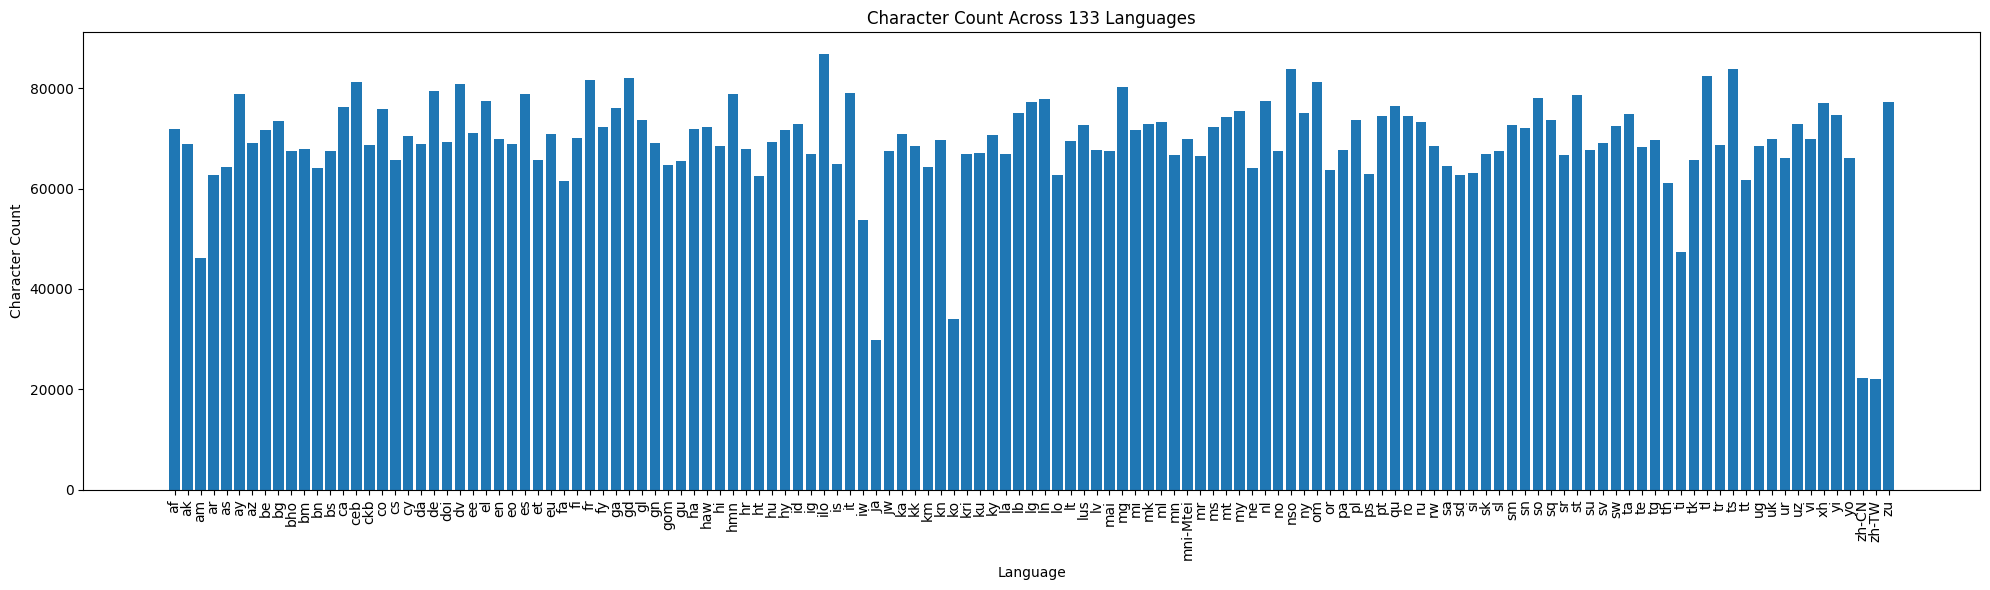

In [ ]:
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
os.makedirs("character_analysis_v2", exist_ok=True)

plt.figure(figsize=(20,6))

plt.bar(df_wiki["Language"], df_wiki["Character Count"])

plt.xticks(rotation=90)

plt.ylabel("Character Count")

plt.xlabel("Language")

plt.title("Character Count Across 133 Languages")

plt.tight_layout()

plt.savefig(
    "character_analysis_v2/Character_Count_Across_133_Languages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

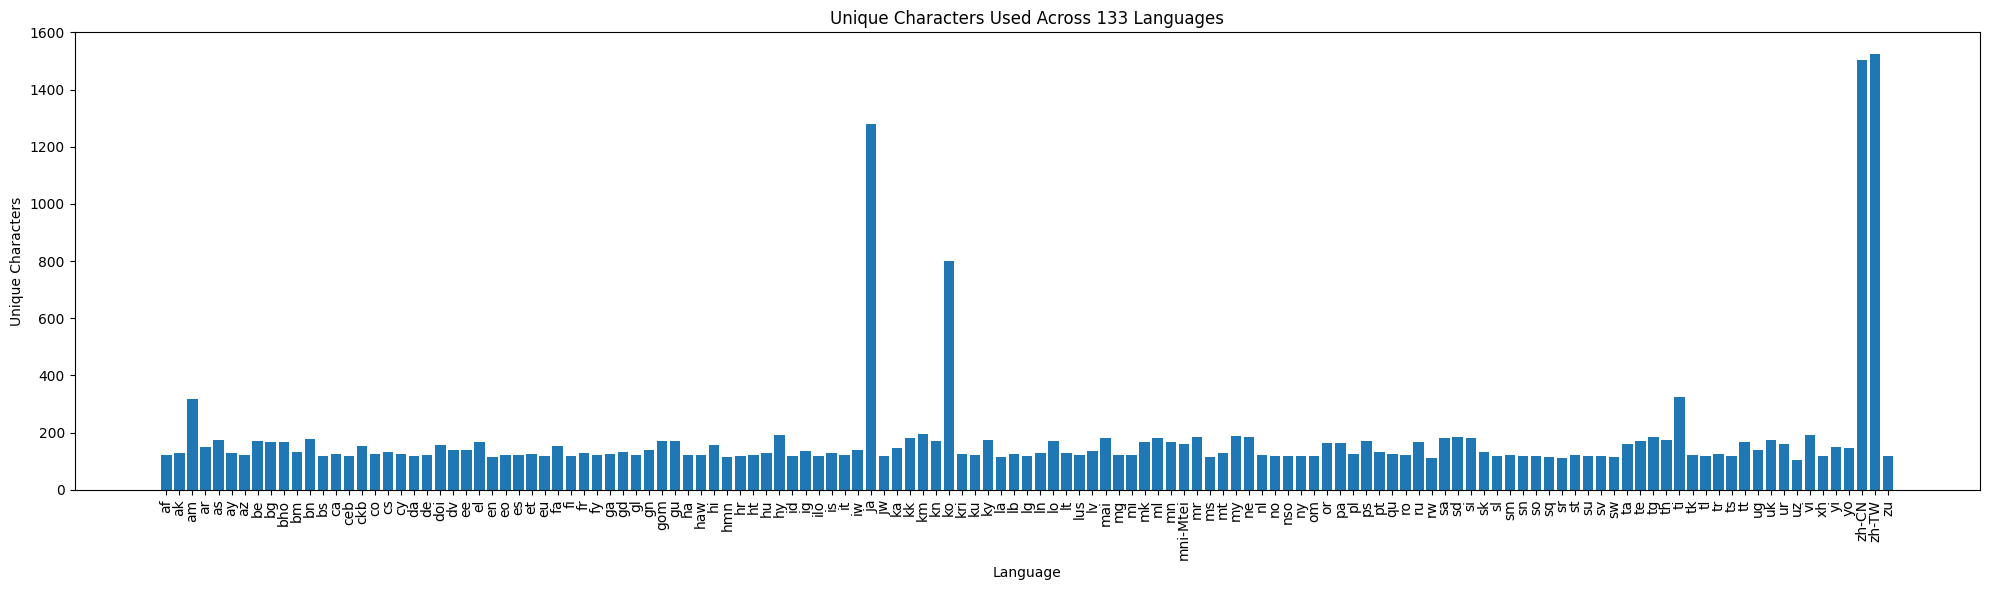

In [ ]:
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
os.makedirs("character_analysis_v2", exist_ok=True)

plt.figure(figsize=(20,6))

plt.bar(df_wiki["Language"], df_wiki["Unique Characters"])

plt.xticks(rotation=90)

plt.xlabel("Language")
plt.ylabel("Unique Characters")

plt.title("Unique Characters Used Across 133 Languages")

plt.tight_layout()

plt.savefig(
    "character_analysis_v2/unique_characters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

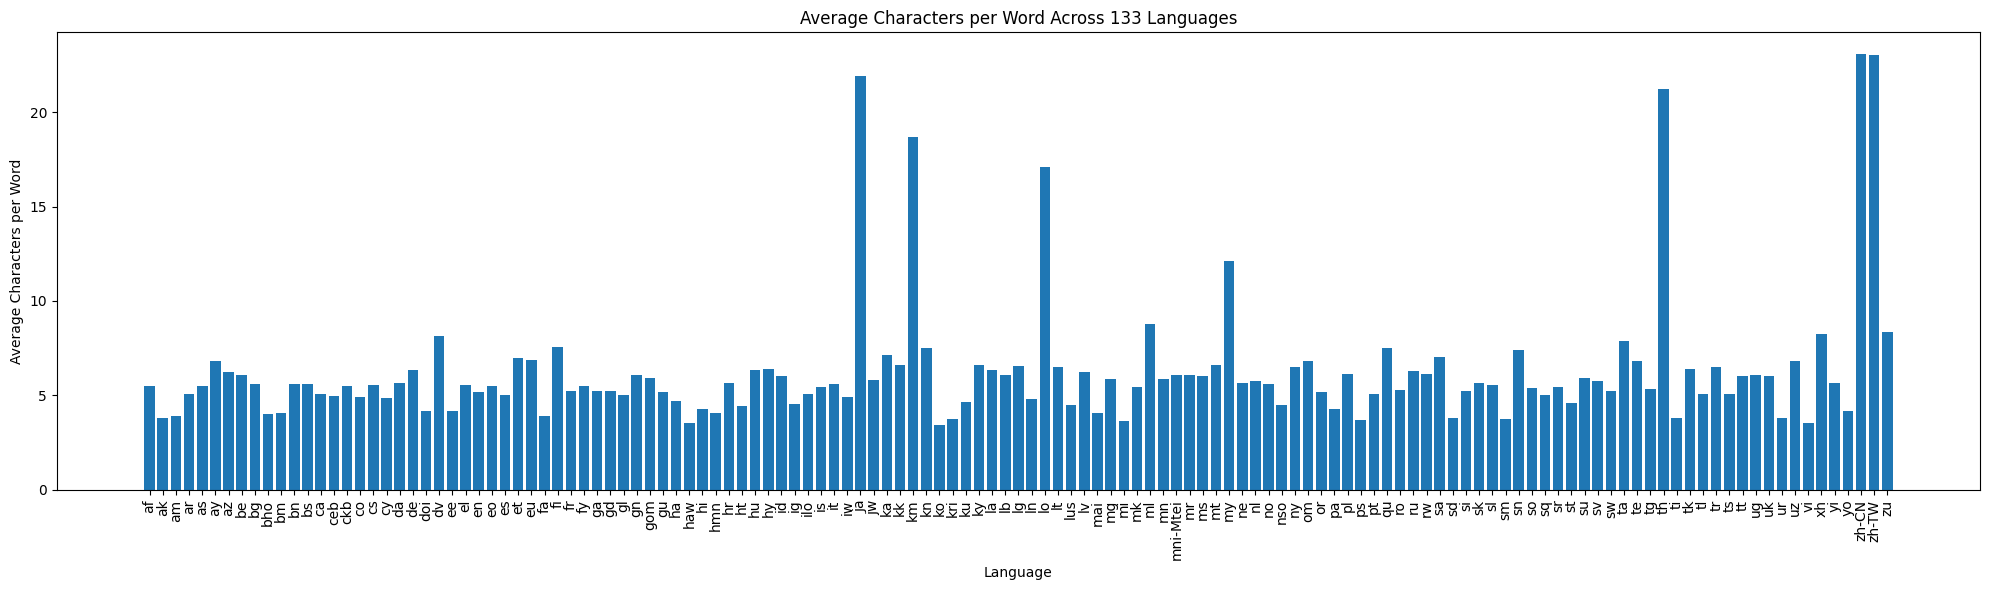

In [ ]:
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
os.makedirs("character_analysis_v2", exist_ok=True)

plt.figure(figsize=(20,6))

plt.bar(df_wiki["Language"], df_wiki["Characters / Word"])

plt.xticks(rotation=90)

plt.xlabel("Language")
plt.ylabel("Average Characters per Word")

plt.title("Average Characters per Word Across 133 Languages")

plt.tight_layout()

plt.savefig(
    "character_analysis_v2/average_characters_per_word.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
df_wiki.to_csv("wikipedia_character_statistics.csv", index=False)
df_wiki.to_pickle("df_wiki.pkl")

In [ ]:
text_ja = get_article_text("ja", "水")  # "水" is Japanese for "water"

with open("wikipedia_texts/ja.txt", "w", encoding="utf-8") as f:
    f.write(text_ja)

print(f"Fetched Japanese '水' article: {len(text_ja)} characters, {len(text_ja.split())} words")

Fetched Japanese '水' article: 13195 characters, 439 words


In [ ]:
os.makedirs("source_wikipedia_ja", exist_ok=True)
os.makedirs("translated_wikipedia_ja", exist_ok=True)

with open("source_wikipedia_ja/input_ja.txt", "w", encoding="utf-8") as f:
    f.write(text_ja)

chunks_ja = split_into_chunks_by_paragraph(text_ja)
print(f"Split into {len(chunks_ja)} chunks")

Split into 4 chunks


In [ ]:
from deep_translator import GoogleTranslator
import time

MAX_SIZE = 1800

def split_text(text, size=MAX_SIZE):
    return [text[i:i+size] for i in range(0, len(text), size)]


def translate_article_from_ja(chunks, target_code):
    translated_chunks = []

    for chunk_no, chunk in enumerate(chunks, start=1):

        # Split large chunk into smaller pieces
        small_chunks = split_text(chunk, MAX_SIZE)

        translated_small = []

        for part_no, part in enumerate(small_chunks, start=1):

            success = False

            for attempt in range(3):   # Retry up to 3 times
                try:
                    result = GoogleTranslator(
                        source="ja",
                        target=target_code
                    ).translate(part)

                    translated_small.append(result)
                    success = True
                    break

                except Exception as e:
                    print(f"{target_code} | Chunk {chunk_no}.{part_no} | Retry {attempt+1}: {e}")
                    time.sleep(3)

            if not success:
                raise Exception(
                    f"Translation failed for {target_code}, chunk {chunk_no}.{part_no}"
                )

            time.sleep(0.5)

        translated_chunks.append("".join(translated_small))

    return "\n\n".join(translated_chunks)

In [ ]:
total = len(supported)
completed = 0
failed = []

os.makedirs("translated_wikipedia_ja", exist_ok=True)

for i, (name, code) in enumerate(supported.items(), start=1):

    out_path = f"translated_wikipedia_ja/{code}.txt"

    if os.path.exists(out_path):
        print(f"[{i}/{total}] {name} -> already done")
        completed += 1
        continue

    try:
        if code == "ja":
            full_translation = text_ja
        else:
            full_translation = translate_article_from_ja(chunks_ja, code)

        with open(out_path, "w", encoding="utf-8") as f:
            f.write(full_translation)

        print(f"[{i}/{total}] {name} -> DONE")
        completed += 1

    except Exception as e:
        print(f"[{i}/{total}] {name} -> FAILED")
        print(e)
        failed.append(code)

    time.sleep(1)

print("\nCompleted:", completed)
print("Failed:", failed)

[1/133] afrikaans -> DONE
[2/133] albanian -> DONE
[3/133] amharic -> DONE
[4/133] arabic -> DONE
[5/133] armenian -> DONE
[6/133] assamese -> DONE
[7/133] aymara -> DONE
[8/133] azerbaijani -> DONE
[9/133] bambara -> DONE
[10/133] basque -> DONE
[11/133] belarusian -> DONE
[12/133] bengali -> DONE
[13/133] bhojpuri -> DONE
[14/133] bosnian -> DONE
[15/133] bulgarian -> DONE
[16/133] catalan -> DONE
[17/133] cebuano -> DONE
[18/133] chichewa -> DONE
[19/133] chinese (simplified) -> DONE
[20/133] chinese (traditional) -> DONE
[21/133] corsican -> DONE
[22/133] croatian -> DONE
[23/133] czech -> DONE
[24/133] danish -> DONE
[25/133] dhivehi -> DONE
[26/133] dogri -> DONE
[27/133] dutch -> DONE
[28/133] english -> DONE
[29/133] esperanto -> DONE
[30/133] estonian -> DONE
[31/133] ewe -> DONE
[32/133] filipino -> DONE
[33/133] finnish -> DONE
[34/133] french -> DONE
[35/133] frisian -> DONE
[36/133] galician -> DONE
[37/133] georgian -> DONE
[38/133] german -> DONE
[39/133] greek -> DONE
[

In [ ]:
TRANSLATED_DIR_JA = "translated_wikipedia_ja"

files_ja = sorted([f for f in os.listdir(TRANSLATED_DIR_JA) if f.endswith(".txt")])
print(f"Found {len(files_ja)} translated files")

results_ja = []
for file in files_ja:
    language = file.replace(".txt", "")
    with open(os.path.join(TRANSLATED_DIR_JA, file), encoding="utf-8") as f:
        text = f.read()
    stats = analyze_text(text)
    stats["Language"] = language
    results_ja.append(stats)

df_wiki_ja = pd.DataFrame(results_ja).sort_values("Language")
df_wiki_ja.to_csv("wikipedia_ja_character_statistics.csv", index=False)
print("Saved: wikipedia_ja_character_statistics.csv")
df_wiki_ja.head(10)

Found 133 translated files
Saved: wikipedia_ja_character_statistics.csv


,Character Count,Character Count (no spaces),Unique Characters,Word Count,Sentence Count,Characters / Word,Language
0,32937,26568,115,5137,235,5.17,af
1,31313,23626,119,6455,257,3.66,ak
2,21169,15779,302,4158,113,3.79,am
3,28347,22509,143,4606,231,4.89,ar
4,29097,23395,166,4470,17,5.23,as
5,34334,28810,125,4292,249,6.71,ay
6,30640,25208,126,4200,234,6.00,az
7,32049,26293,163,4524,250,5.81,be
8,32383,26150,162,5001,259,5.23,bg
9,31013,23739,144,6042,28,3.93,bho


In [ ]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

display(df_wiki_ja)

,Character Count,Character Count (no spaces),Unique Characters,Word Count,Sentence Count,Characters / Word,Language
0,32937,26568,115,5137,235,5.17,af
1,31313,23626,119,6455,257,3.66,ak
2,21169,15779,302,4158,113,3.79,am
3,28347,22509,143,4606,231,4.89,ar
4,29097,23395,166,4470,17,5.23,as
5,34334,28810,125,4292,249,6.71,ay
6,30640,25208,126,4200,234,6.00,az
7,32049,26293,163,4524,250,5.81,be
8,32383,26150,162,5001,259,5.23,bg
9,31013,23739,144,6042,28,3.93,bho


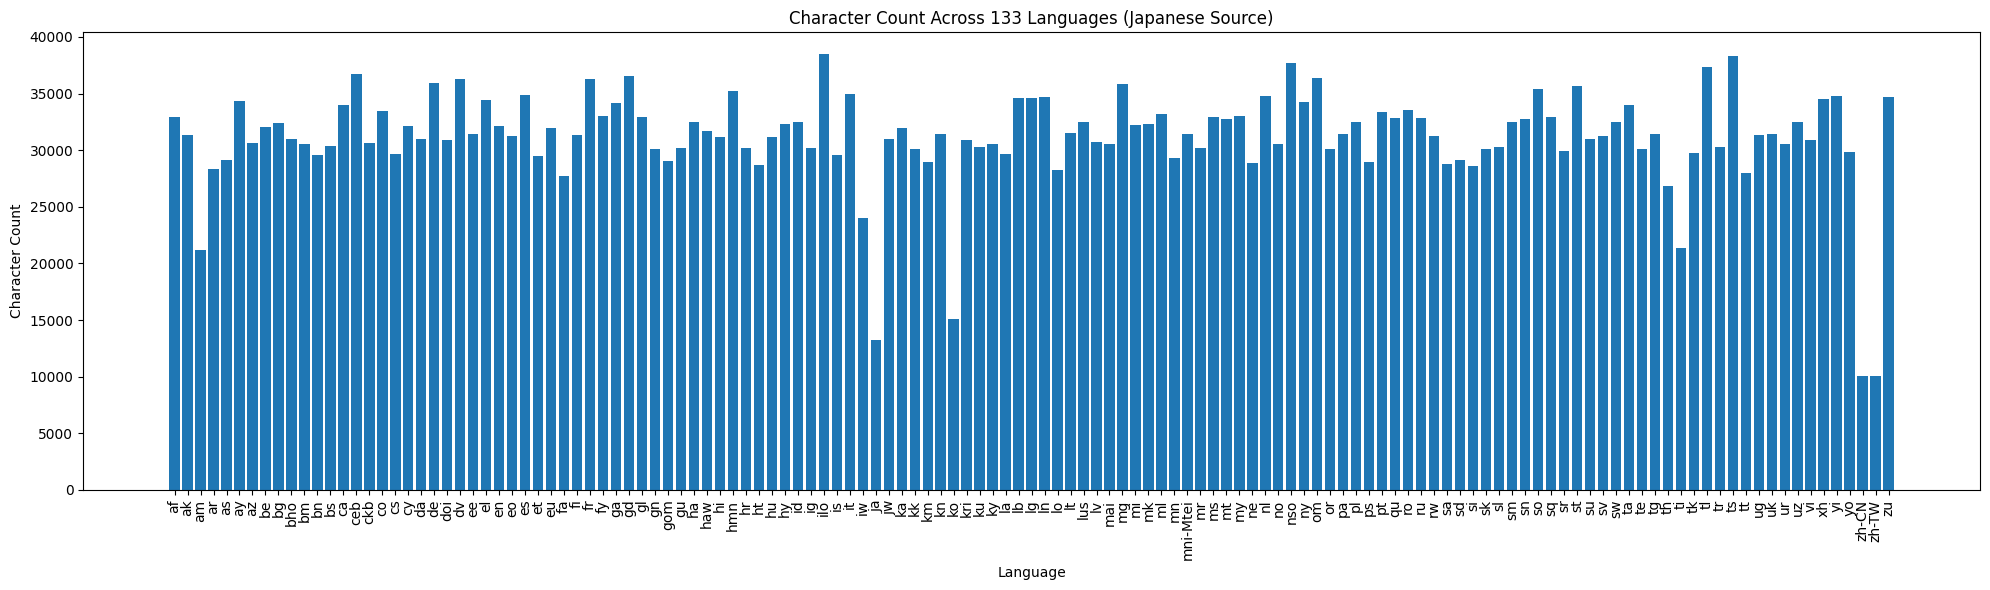

In [ ]:
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
os.makedirs("character_analysis_v2", exist_ok=True)

plt.figure(figsize=(20,6))

plt.bar(df_wiki_ja["Language"], df_wiki_ja["Character Count"])

plt.xticks(rotation=90)

plt.ylabel("Character Count")

plt.xlabel("Language")

plt.title("Character Count Across 133 Languages (Japanese Source)")

plt.tight_layout()

plt.savefig(
    "character_analysis_v2/Character_Count_Across_133_Languages_Japanese.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

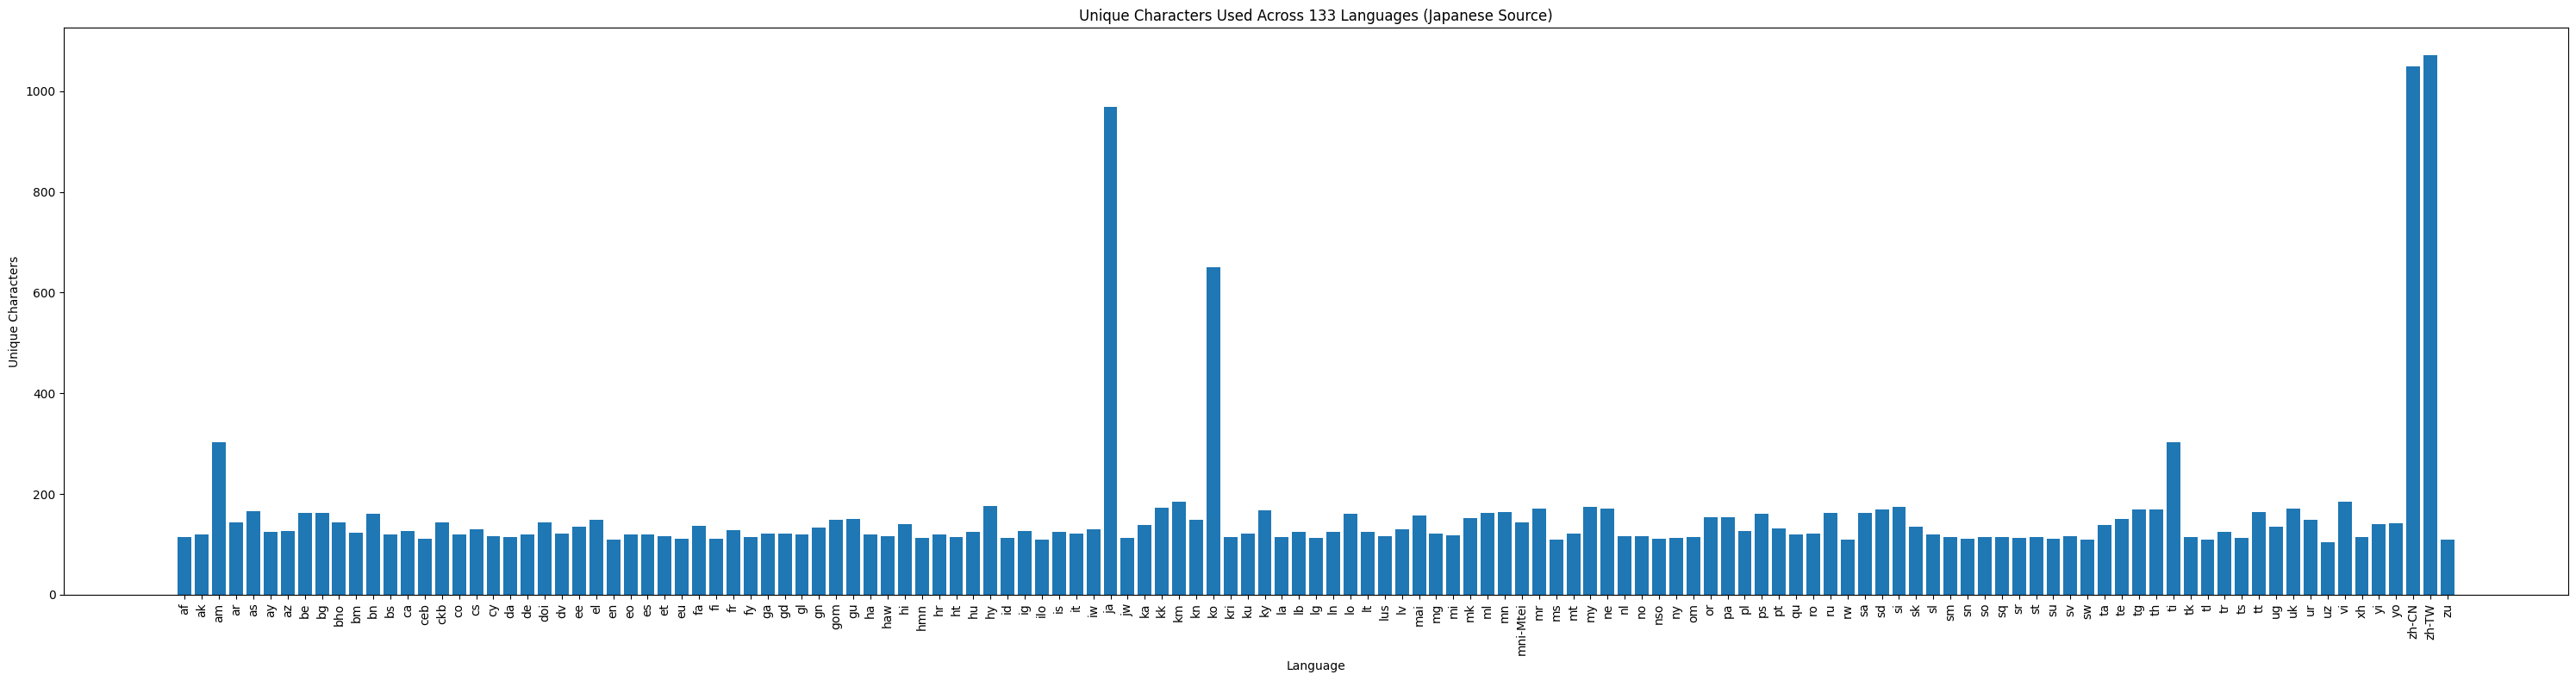

In [ ]:
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
os.makedirs("character_analysis_v2", exist_ok=True)

plt.figure(figsize=(30,8))   # Wider figure for 133 languages

plt.bar(df_wiki_ja["Language"], df_wiki_ja["Unique Characters"])

plt.xticks(rotation=90)

plt.xlabel("Language")
plt.ylabel("Unique Characters")

plt.title("Unique Characters Used Across 133 Languages (Japanese Source)")

plt.tight_layout()

plt.savefig(
    "character_analysis_v2/Unique_Characters_Across_133_Languages_Japanese.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

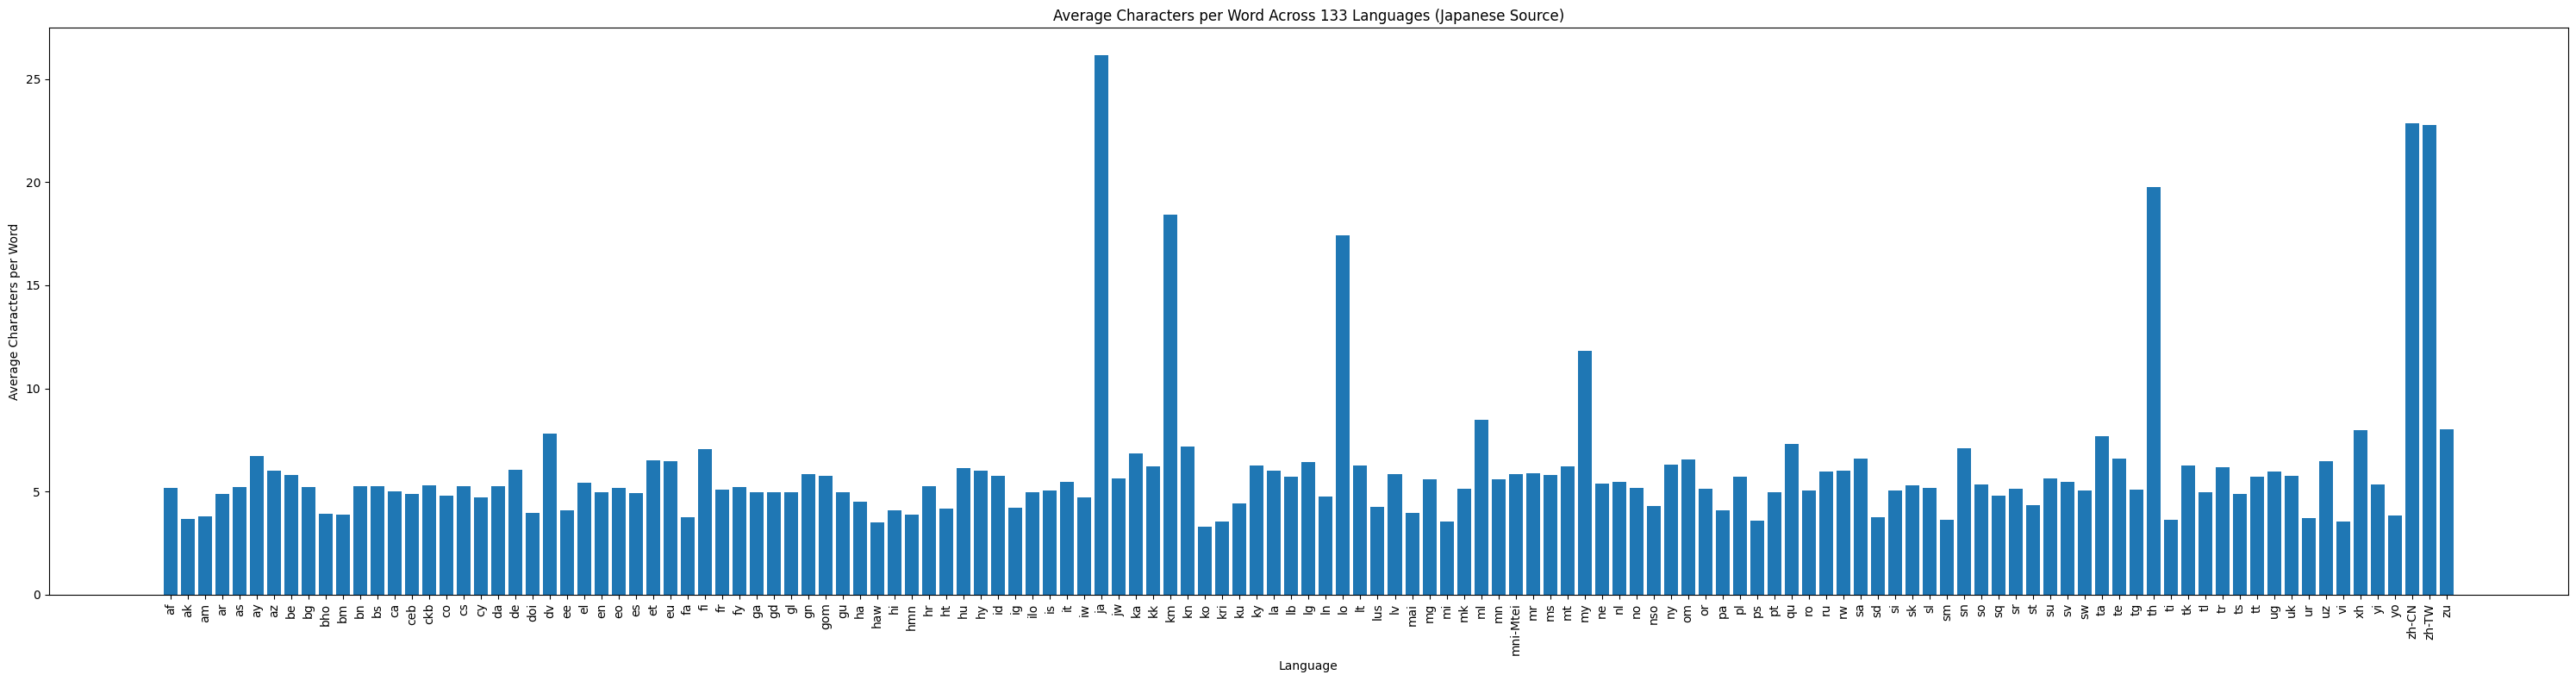

In [ ]:
import matplotlib.pyplot as plt
import os

# Create output folder if it doesn't exist
os.makedirs("character_analysis_v2", exist_ok=True)

plt.figure(figsize=(30,8))   # Wider figure for 133 languages

plt.bar(df_wiki_ja["Language"], df_wiki_ja["Characters / Word"])

plt.xticks(rotation=90)

plt.xlabel("Language")
plt.ylabel("Average Characters per Word")

plt.title("Average Characters per Word Across 133 Languages (Japanese Source)")

plt.tight_layout()

plt.savefig(
    "character_analysis_v2/Average_Characters_Per_Word_Japanese.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
comparison_en_ja = df_wiki[["Language", "Character Count"]].merge(
    df_wiki_ja[["Language", "Character Count"]],
    on="Language",
    suffixes=("_from_english", "_from_japanese")
)

correlation = comparison_en_ja["Character Count_from_english"].corr(
    comparison_en_ja["Character Count_from_japanese"]
)
print(f"Correlation between English-sourced and Japanese-sourced character counts: {correlation:.3f}")

comparison_en_ja.to_csv("english_vs_japanese_source_comparison.csv", index=False)

print("\nSmallest by English-sourced:")
print(comparison_en_ja.sort_values("Character Count_from_english").head(10))

print("\nSmallest by Japanese-sourced:")
print(comparison_en_ja.sort_values("Character Count_from_japanese").head(10))

Correlation between English-sourced and Japanese-sourced character counts: 0.994

Smallest by English-sourced:
    Language  Character Count_from_english  Character Count_from_japanese
131    zh-TW                         22058                          10050
130    zh-CN                         22347                          10065
54        ja                         29928                          13195
60        ko                         34029                          15106
2         am                         46181                          21169
116       ti                         47425                          21317
53        iw                         53739                          24014
115       th                         61049                          26794
30        fa                         61496                          27715
121       tt                         61712                          28026

Smallest by Japanese-sourced:
    Language  Character Count_from_english  